In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Ejection_Results/12048778_ejection_results.txt', header=None)

In [4]:
df2=pd.read_csv('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Ejection_Results/12257263_ejection_results.txt', header=None)

In [5]:
df3=pd.concat([df, df2])

In [36]:
df=df3

In [37]:
pd.concat?

Signature:
pd.concat(
    objs: 'Iterable[Series | DataFrame] | Mapping[HashableT, Series | DataFrame]',
    *,
    axis: 'Axis' = 0,
    join: 'str' = 'outer',
    ignore_index: 'bool' = False,
    keys: 'Iterable[Hashable] | None' = None,
    levels=None,
    names: 'list[HashableT] | None' = None,
    verify_integrity: 'bool' = False,
    sort: 'bool' = False,
    copy: 'bool | None' = None,
) -> 'DataFrame | Series'
Docstring:
Concatenate pandas objects along a particular axis.

Allows optional set logic along the other axes.

Can also add a layer of hierarchical indexing on the concatenation axis,
which may be useful if the labels are the same (or overlapping) on
the passed axis number.

Parameters
----------
objs : a sequence or mapping of Series or DataFrame objects
    If a mapping is passed, the sorted keys will be used as the `keys`
    argument, unless it is passed, in which case the values will be
    selected (see below). Any None objects will be dropped silently unless
  

In [38]:
df


,0,1,2
0,0.0003,1,0.0
1,0.0003,1,0.0
2,0.0003,1,0.0
3,0.0003,1,0.0
4,0.0003,1,0.0
...,...,...,...
8092017,0.0003,1,3995000.0
8092018,0.0003,1,3996000.0
8092019,0.0003,1,3997000.0
8092020,0.0003,1,3998000.0


In [39]:
df.columns = ['mass','result','time']

In [40]:
grouped = (
    df.groupby(["mass", "time"])
      .agg(
          total_particles=("result", "size"),
          ejected_particles=("result", lambda x: (x == 0).sum())
      )
      .reset_index()
)

grouped["ejection_fraction"] = (
    grouped["ejected_particles"] / grouped["total_particles"]
)

In [41]:
grouped

,mass,time,total_particles,ejected_particles,ejection_fraction
0,0.000300,0.0,4200,0,0.000000
1,0.000300,1000.0,4200,0,0.000000
2,0.000300,2000.0,4200,0,0.000000
3,0.000300,3000.0,4200,0,0.000000
4,0.000300,4000.0,4200,0,0.000000
...,...,...,...,...,...
5675,0.009496,95000.0,3900,2383,0.611026
5676,0.009496,96000.0,3900,2385,0.611538
5677,0.009496,97000.0,3900,2385,0.611538
5678,0.009496,98000.0,3900,2386,0.611795


In [42]:
grouped['delta_f'] = grouped['ejection_fraction']-grouped['ejection_fraction'].shift(10)

In [43]:
grouped['relative_error'] = grouped['delta_f']/grouped['ejection_fraction'].shift(10)

In [44]:
peak_time_by_mass = (
    grouped.loc[grouped.groupby("mass")["delta_f"].idxmax()]
           .set_index("mass")["time"]
)

In [45]:
peak_time_by_mass

mass
0.000300    198000.0
0.000712     51000.0
0.001689     20000.0
0.004004     14000.0
0.009496     12000.0
Name: time, dtype: float64

In [46]:
grouped['past peak'] = grouped['mass'].map(peak_time_by_mass) < grouped['time']

In [47]:
grouped['below_tol'] = grouped['relative_error'] ==0.0
grouped["meets criterion"] = grouped['below_tol'] & grouped['past peak']

In [48]:
slope_times=grouped.loc[grouped["past peak"] & grouped['below_tol']].groupby("mass")["time"].min()

In [49]:
mask = (np.isclose(grouped["mass"].to_numpy(), 0.000300, rtol=1e-2)) & (np.isclose(grouped["time"].to_numpy(),  604000.0, atol=1e2))

matching_rows = grouped.loc[mask]

In [50]:
matching_rows

,mass,time,total_particles,ejected_particles,ejection_fraction,delta_f,relative_error,past peak,below_tol,meets criterion
604,0.0003,604000.0,4071,1938,0.47605,0.003439,0.007277,True,False,False


In [51]:
slope_times


mass
0.000300    1013000.0
0.000712     335000.0
0.001689     240000.0
0.004004     129000.0
0.009496      78000.0
Name: time, dtype: float64

[1013000.]
[335000.]
[240000.]
[129000.]
[78000.]


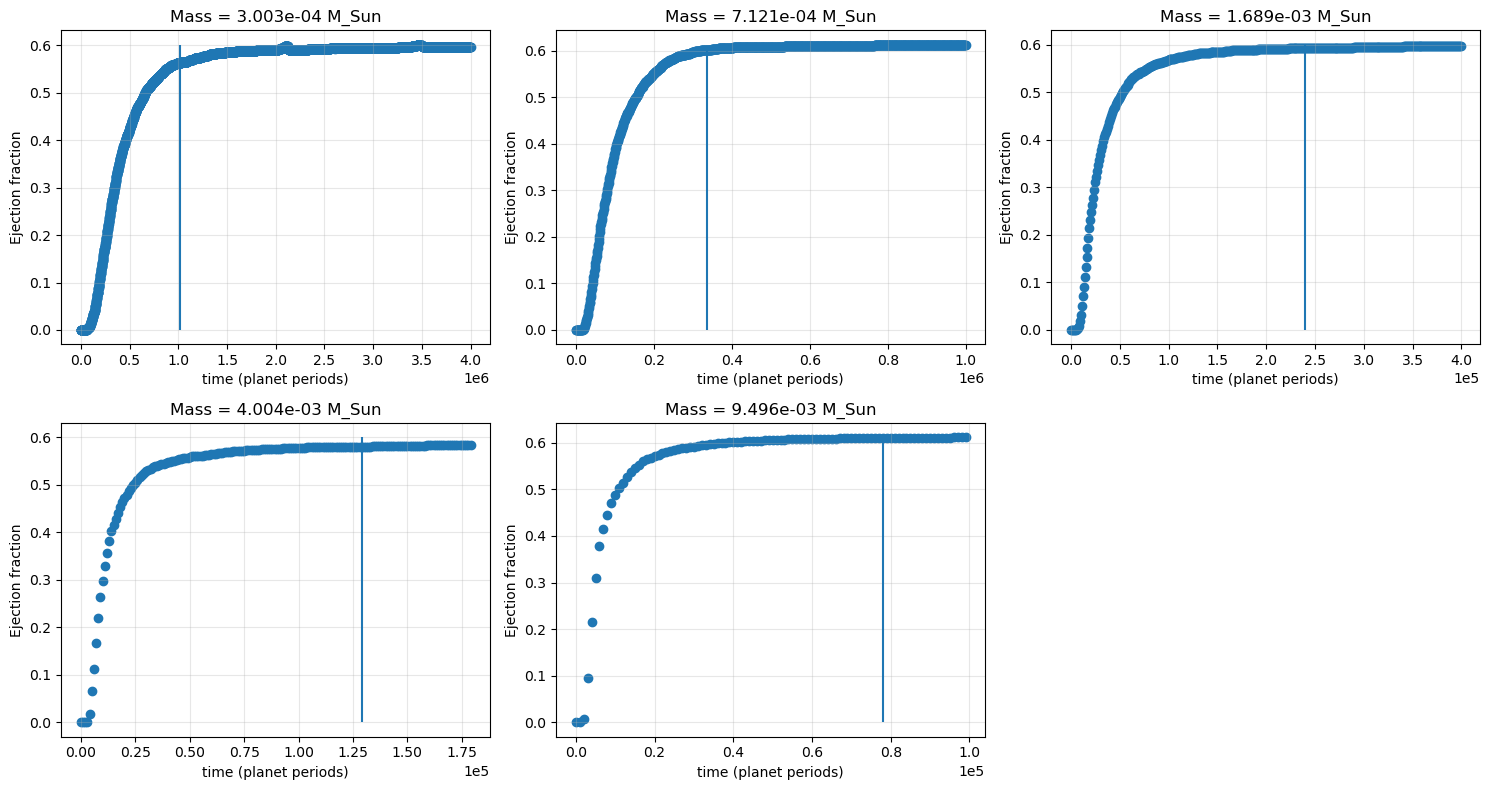

In [52]:
masses = np.sort(grouped["mass"].unique())

ncols = 3
nrows = int(np.ceil(len(masses) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 4 * nrows),
    sharex=False,
    sharey=False,
)

axes = np.atleast_1d(axes).ravel()

for ax, mass in zip(axes, masses):
    mass_df = (
        grouped[grouped["mass"] == mass]
        .sort_values("time")
    )

    ax.scatter(
        mass_df["time"],
        mass_df["ejection_fraction"],
    )

    mass_values = slope_times.index.to_numpy(dtype=float)

    mask = np.isclose(
        mass_values,
        mass,
        rtol=1e-2,

    )

    crit_time = slope_times.iloc[np.flatnonzero(mask)].to_numpy()

    print(crit_time)
    ax.vlines(crit_time,0,0.6)


    ax.set_title(f"Mass = {mass:.3e} M_Sun")
    ax.set_xlabel("time (planet periods)")
    ax.set_ylabel("Ejection fraction")
    ax.grid(alpha=0.3)

    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

    # Optional if tmax spans orders of magnitude
    # ax.set_xscale("log")

for ax in axes[len(masses):]:
    ax.remove()

fig.tight_layout()